In [ ]:
# Código para expandir la vista en el monitor

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# FUNCIONES A PASAR A .py

In [1]:
def conf_matrix_train_val(Y_train, Y_train_pred, Y_test, Y_test_pred):
    # Train Confusion Matrix 
    cf_matrix_train = confusion_matrix(Y_train, Y_train_pred)
    group_names_train = ["True Neg", "False Pos", "False Neg", "True Pos"]
    group_counts_train = ["{0:0.0f}".format(value) for value in cf_matrix_train.flatten()]
    labels_train = [f"{v1}\n{v2}" for v1, v2 in zip(group_names_train, group_counts_train)]
    labels_train = np.asarray(labels_train).reshape(2,2)
    
    # Validation Confusion Matrix     
    cf_matrix_test = confusion_matrix(Y_test, Y_test_pred)
    group_names_test = ["True Neg", "False Pos", "False Neg", "True Pos"]
    group_counts_test = ["{0:0.0f}".format(value) for value in cf_matrix_test.flatten()]
    labels_test = [f"{v1}\n{v2}" for v1, v2 in zip(group_names_test, group_counts_test)]
    labels_test = np.asarray(labels_test).reshape(2,2)
    
    # Graphics
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
    sns.heatmap(cf_matrix_train, annot = labels_train, annot_kws = {'size': 14}, fmt = "", cmap = ListedColormap(["white"]), cbar = False, linewidths = 4, linecolor = 'black', ax = ax[0])
    sns.heatmap(cf_matrix_test, annot = labels_test, annot_kws = {'size': 14}, fmt = "", cmap = ListedColormap(["white"]), cbar = False, linewidths = 4, linecolor = 'black', ax = ax[1])
    
    # Titles, labels, ticks, etc
    ax[0].set_title("Train Confusion Matrix", fontsize = 20)
    ax[1].set_title("Validation Confusion Matrix", fontsize = 20)
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    plt.show()
    
    print("---" * 34)

In [2]:
def roc_curve_graph_train_val(y_test, y_test_pred_proba):
    fpr, tpr, thr = roc_curve(y_test, y_test_pred_proba) 

    plt.figure(figsize = (8,8))

    plt.plot(fpr, tpr, color = "black")
    plt.plot(np.arange(0,1, step =0.01), np.arange(0,1, step =0.01), color = "darkgreen", linestyle = "--")

    plt.title("Validation ROC Curve", fontsize = 18) 
    plt.xlabel("1 - Specificty", fontsize = 16)
    plt.ylabel("Sensitivity", fontsize = 16)

    plt.ylim(0,1)
    plt.xlim(0,1)
    plt.yticks(ticks = [0,0.2,0.4,0.6,0.8,1], labels = ["",0.2,0.4,0.6,0.8,1], fontsize = 14)
    plt.xticks(fontsize = 14)

    style = dict(size = 14, color = "black", fontstyle = "oblique")
    props = dict(boxstyle = "round", facecolor = "grey", alpha=0.5)

    auc_score = round(auc(fpr, tpr), 2)

    plt.text(0.85, 0.1, f"AUC = {auc_score}", ha = "center", va = "bottom", **style, bbox = props)

    plt.show()
    
    print("---" * 34)

In [3]:
def metrics_train_val(Y_train, Y_test, Y_train_pred, Y_test_pred, Y_train_pred_proba, Y_test_pred_proba):
    #scoring = {"recall" : "recall", "precision": "precision", "roc_auc": "roc_auc"}
    #recalls = cross_validate(estimator = model, X = X_train_std, y = Y_train, cv = 3, verbose = 1, scoring = scoring)
    print(f"\tTrain Precision Score:{precision_score(Y_train, Y_train_pred):.3f}")
    print(f"\tValidation Precision Score:{precision_score(Y_test, Y_test_pred):.3f}")
    print("\t---" * 4)
    print(f"\tTrain Recall Score:{recall_score(Y_train, Y_train_pred):.3f}")
    print(f"\tValidation Recall Score:{recall_score(Y_test, Y_test_pred):.3f}")
    print("\t---" * 4)
    print(f"\tTrain ROC AUC Score:{roc_auc_score(Y_train, Y_train_pred_proba):.3f}")
    print(f"\tValidation ROC AUC Score:{roc_auc_score(Y_test, Y_test_pred_proba):.3f}")
    print("---" * 34)

In [4]:
def fit_train_val(model):
    print("For", str(model).split("(")[0],":")
    global fit
    fit = model.fit(X_train_std, y_train.values.reshape(-1,))
    
    y_train_pred = model.predict(X_train_std)
    y_val_pred = model.predict(X_val_std)
    
    y_train_pred_proba = model.predict_proba(X_train_std)[:, 1]
    y_val_pred_proba = model.predict_proba(X_val_std)[:, 1]

    metrics_train_val(y_train, y_val, y_train_pred, y_val_pred, y_train_pred_proba, y_val_pred_proba)
    
    conf_matrix_train_val(y_train, y_train_pred, y_val, y_val_pred)
    roc_curve_graph_train_val(y_val, y_val_pred_proba)
    print(classification_report(y_val, y_val_pred))

# 1. Load basic modules and the csv file 

In [5]:
# Basic libraries
from datetime import datetime
#inicial_date = datetime.now()
import pandas as pd
import numpy as np
import datetime

# Visualization libraries
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

# Data preprocessing libraries
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

# Machine Learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC

# Metrics libraries
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, auc, classification_report, ConfusionMatrixDisplay

In [6]:
data = pd.read_csv("../documents/data_model.csv")

In [7]:
data.shape

(300937, 14)

In [8]:
data.head()

,Age,Driving_License,Previously_Insured,Annual_Premium,Vintage,Response,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes,Policy_Sales_Channel_152.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_26.0,Policy_Sales_Channel_other
0,44,1,0,40454.0,217,1,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,76,1,0,33536.0,183,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,47,1,0,38294.0,27,1,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,21,1,1,28619.0,203,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,29,1,1,27496.0,39,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300937 entries, 0 to 300936
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Age                         300937 non-null  int64  
 1   Driving_License             300937 non-null  int64  
 2   Previously_Insured          300937 non-null  int64  
 3   Annual_Premium              300937 non-null  float64
 4   Vintage                     300937 non-null  int64  
 5   Response                    300937 non-null  int64  
 6   Gender_Male                 300937 non-null  float64
 7   Vehicle_Age_< 1 Year        300937 non-null  float64
 8   Vehicle_Age_> 2 Years       300937 non-null  float64
 9   Vehicle_Damage_Yes          300937 non-null  float64
 10  Policy_Sales_Channel_152.0  300937 non-null  float64
 11  Policy_Sales_Channel_160.0  300937 non-null  float64
 12  Policy_Sales_Channel_26.0   300937 non-null  float64
 13  Policy_Sales_C

# 2. train_test_split 

Aclarar por qué se elige X_val, que es porque ya existe un set de testeo

In [10]:
X = data.drop(["Response"], axis = 1)
y = data["Response"]

In [11]:
response_abs = y.value_counts()
response_pct = y.value_counts(normalize = True).round(2) * 100

In [12]:
response_abs

0    264042
1     36895
Name: Response, dtype: int64

In [13]:
response_pct

0    88.0
1    12.0
Name: Response, dtype: float64

In [14]:
def addlabels_abs(a, b):
    for i in range(len(a)):
        plt.text(a.index[i], b[i], '{:,}'.format(a[i]), ha = "center", fontsize = 20, bbox = dict(facecolor = "white", alpha = .75))

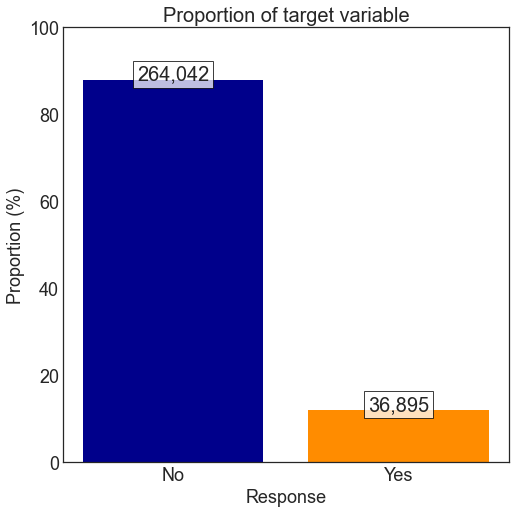

In [15]:
plt.style.use("seaborn-white")
sns.set_palette("vlag")
fig, ax = plt.subplots(figsize = (8, 8))

colors = ["darkblue", "darkorange"]
ax.bar(response_pct.index, response_pct, color = colors)

plt.ylabel("Proportion (%)", fontsize = 18)
plt.xlabel("Response", fontsize = 18)
plt.yticks(fontsize = 18)
plt.xticks(ticks = [0, 1], labels = ["No", "Yes"], fontsize = 18)
plt.title("Proportion of target variable", fontsize = 20)
plt.ylim(0, 100)

addlabels_abs(response_abs, response_pct)

plt.show()

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 123)

In [17]:
X_train.head()

,Age,Driving_License,Previously_Insured,Annual_Premium,Vintage,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes,Policy_Sales_Channel_152.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_26.0,Policy_Sales_Channel_other
69522,44,1,0,31799.0,32,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
204430,21,1,0,32375.0,111,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
178085,75,1,0,27728.0,35,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
31668,47,1,1,30654.0,204,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
127331,24,1,0,29049.0,114,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [18]:
print(f"X_train.shape:{X_train.shape}")
print(f"y_train.shape:{y_train.shape}")
print("---" * 10)
print(f"X_val.shape:{X_val.shape}")
print(f"y_val.shape:{y_val.shape}")

X_train.shape:(240749, 13)
y_train.shape:(240749,)
------------------------------
X_val.shape:(60188, 13)
y_val.shape:(60188,)


# 3. StandardScaler

In [19]:
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_val_std = std.transform(X_val)

In [20]:
X_train_std = pd.DataFrame(X_train_std, columns = X_train.columns)

In [21]:
X_val_std = pd.DataFrame(X_val_std, columns = X_val.columns)

# 4 Models 

In [22]:
model_results = pd.DataFrame({"Model": [], 
                              "Train Recall": [], "Validation Recall": [], 
                              "Train Precision": [], "Validation Precision": [],
                              "Val TP": [], "Val FP": [], "Val TN": [], "Val FN": [],
                              "Train AUC": [], "Validation AUC": []})

In [23]:
model_results

,Model,Train Recall,Validation Recall,Train Precision,Validation Precision,Val TP,Val FP,Val TN,Val FN,Train AUC,Validation AUC


<a id='4.A'></a>

## A. RandomForestClassifier()

<a id='4.A.1'></a>

### A.1 Without tuning hyperparameters

In [24]:
rf = RandomForestClassifier(random_state = 123)

For RandomForestClassifier :
	Train Precision Score:1.000
	Validation Precision Score:0.344
	---	---	---	---
	Train Recall Score:1.000
	Validation Recall Score:0.157
	---	---	---	---
	Train ROC AUC Score:1.000
	Validation ROC AUC Score:0.830
------------------------------------------------------------------------------------------------------


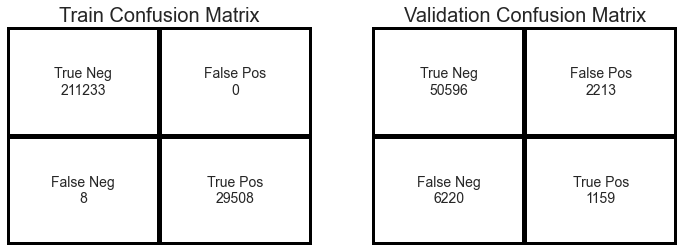

------------------------------------------------------------------------------------------------------


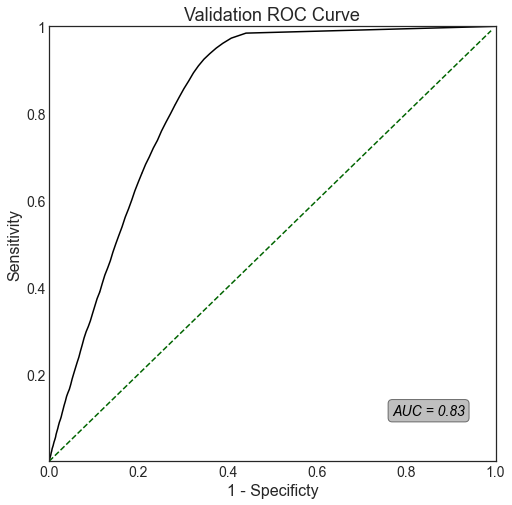

------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     52809
           1       0.34      0.16      0.22      7379

    accuracy                           0.86     60188
   macro avg       0.62      0.56      0.57     60188
weighted avg       0.82      0.86      0.84     60188



In [25]:
fit_train_val(rf)

<a id='4.A.2'></a>

#### A.1.1 RF without tuning hyperparameters append results

In [26]:
rf_train_recall = round(recall_score(y_train, rf.predict(X_train_std)), 2)
rf_val_recall = round(recall_score(y_val, rf.predict(X_val_std)), 2)

rf_train_precision = round(precision_score(y_train, rf.predict(X_train_std)), 2)
rf_val_precision = round(precision_score(y_val, rf.predict(X_val_std)), 2)

rf_train_auc = round(roc_auc_score(y_train, rf.predict_proba(X_train_std)[:, 1]), 2)
rf_val_auc = round(roc_auc_score(y_val, rf.predict_proba(X_val_std)[:, 1]), 2)

rf_val_cf_matrix = confusion_matrix(y_val, rf.predict(X_val_std))

In [27]:
rf_results = pd.DataFrame({"Model": ["RF without tunning"], 
                           "Train Recall": [rf_train_recall], "Validation Recall": [rf_val_recall], 
                           "Train Precision": [rf_train_precision], "Validation Precision": [rf_val_precision], 
                           "Val TP": [rf_val_cf_matrix[1,1]], "Val FP": [rf_val_cf_matrix[1,0]], "Val TN": [rf_val_cf_matrix[0,0]], "Val FN": [rf_val_cf_matrix[0,1]],
                           "Train AUC": [rf_train_auc], "Validation AUC": [rf_val_auc]})

In [28]:
model_results = pd.concat([model_results, rf_results], axis = 0, ignore_index = True)

### A.2 hyperparameters tuning

JUSTIFICAR XQ CORRO ATRAS DEL AUC

<a id='4.A.2.1'></a>

#### A.2.1 n_estimators

In [29]:
n_estimators = [10, 50, 100, 500, 1000, 3000]

In [30]:
start = datetime.datetime.now()

eje_x = []
eje_y_train = []
eje_y_val = []

for i in n_estimators:    
    # We instantiate the model
    rf_clf = RandomForestClassifier(n_estimators = i, random_state = 123)
    
    # Fitting
    rf_clf.fit(X_train_std, y_train)
    
    # Predicting
    y_train_pred_proba_rf = rf_clf.predict_proba(X_train_std)
    y_val_pred_proba_rf = rf_clf.predict_proba(X_val_std)

    # AUC
    train_roc_auc_score_rf = roc_auc_score(y_train, y_train_pred_proba_rf[:, 1])
    val_roc_auc_score_rf = roc_auc_score(y_val, y_val_pred_proba_rf[:, 1])
    
    # Appending
    eje_x.append(i)
    eje_y_train.append(train_roc_auc_score_rf)
    eje_y_val.append(val_roc_auc_score_rf)
    
end = datetime.datetime.now()
delta = round((end - start).seconds / 60, 2)
print(f"Time it took to search n_estimators: {delta} minutes.")

Time it took to search n_estimators: 16.78 minutes.


In [31]:
eje_y_train

[0.9993002410295235,
 0.999999864950549,
 0.999999999358435,
 0.9999999996792175,
 0.9999999996792174,
 0.9999999996792175]

In [32]:
eje_y_val

[0.7849675228069493,
 0.8261227959026879,
 0.8302782386437901,
 0.8341392354204307,
 0.834814887530195,
 0.8352853636233158]

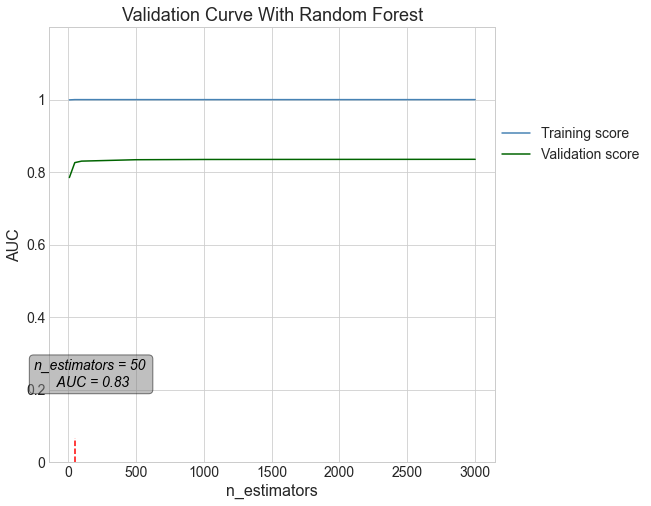

In [33]:
plt.style.use("seaborn-whitegrid")

plt.subplots(1, figsize = (8, 8))

plt.plot(eje_x, eje_y_train, label = "Training score", color = "steelblue")
plt.plot(eje_x, eje_y_val, label = "Validation score", color = "darkgreen")

plt.title("Validation Curve With Random Forest", fontsize = 18)
plt.xlabel("n_estimators", fontsize = 16)
plt.ylabel("AUC", fontsize = 16)

plt.yticks(ticks = [0, 0.2, 0.4, 0.6, 0.8, 1], labels = [0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 14) 
plt.xticks(fontsize = 14)
plt.ylim(0, 1.2)


plt.axvline(50, ymax = 0.055, color = "red", linestyle = "--")
style = dict(size = 14, color = 'black', fontstyle = "oblique")
props = dict(boxstyle = "round", facecolor = "grey", alpha=0.5)
plt.text(170, 0.2, f"n_estimators = 50 \n AUC = {eje_y_val[1].round(2)}", ha = "center", va = "bottom", **style, bbox = props)

plt.legend(fontsize = 14, bbox_to_anchor = (1.35, 0.8))

plt.show()

`n_estimators = ???` will be used as a reference value.

<a id='4.A.2.2'></a>

#### A.2.2 max_depth

In [34]:
max_depth = [1,2,3,4,5,10,11,12,13,14,15,20,30, 50, 100]

In [35]:
start = datetime.datetime.now()

eje_x = []
eje_y_train = []
eje_y_val = []

for i in max_depth:    
    # We instantiate the model
    rf_clf = RandomForestClassifier(max_depth = i, random_state = 123)
    
    # Fitting
    rf_clf.fit(X_train_std, y_train)
    
    # Predicting
    y_train_pred_proba_rf = rf_clf.predict_proba(X_train_std)
    y_val_pred_proba_rf = rf_clf.predict_proba(X_val_std)

    # AUC
    train_roc_auc_score_rf = roc_auc_score(y_train, y_train_pred_proba_rf[:, 1])
    val_roc_auc_score_rf = roc_auc_score(y_val, y_val_pred_proba_rf[:, 1])
    
    # Appending
    eje_x.append(i)
    eje_y_train.append(train_roc_auc_score_rf)
    eje_y_val.append(val_roc_auc_score_rf)
    
end = datetime.datetime.now()
delta = round((end - start).seconds / 60, 2)
print(f"Time it took to search max_depth: {delta} minutes.")

Time it took to search max_depth: 3.02 minutes.


In [36]:
eje_y_train

[0.8207528078286918,
 0.8378339004727005,
 0.8442202830677937,
 0.8514952298606036,
 0.8551035382695021,
 0.8659080503386365,
 0.8700989286371801,
 0.8754390698235988,
 0.8817147795540626,
 0.8901320323435262,
 0.9002610374846419,
 0.9615312635113006,
 0.9999814321440215,
 0.9999999987168698,
 0.999999999358435]

In [37]:
eje_y_val

[0.8213877086204987,
 0.8382364646553945,
 0.844406950031317,
 0.8518073213089987,
 0.8550465464129526,
 0.8585275855122199,
 0.8583600200731061,
 0.8583020054493199,
 0.8581932129531559,
 0.8576609088275282,
 0.8570761959942317,
 0.8501253976328653,
 0.8353135420448881,
 0.8303048426869976,
 0.8302782386437901]

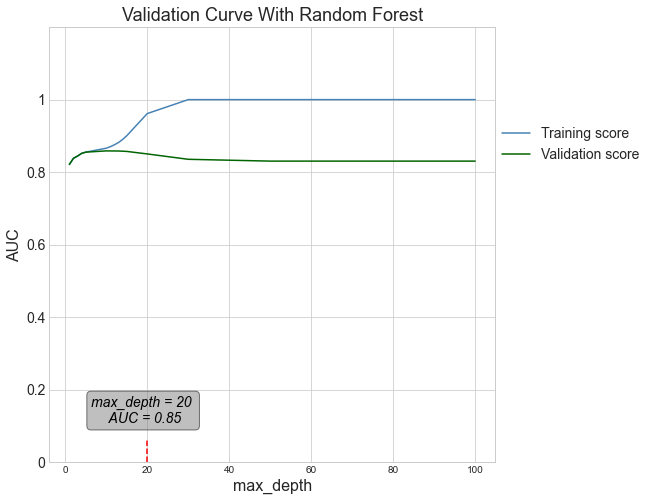

In [38]:
plt.style.use("seaborn-whitegrid")

plt.subplots(1, figsize = (8,8))

plt.plot(eje_x, eje_y_train, label = "Training score", color = "steelblue")
plt.plot(eje_x, eje_y_val, label = "Validation score", color = "darkgreen")

plt.title("Validation Curve With Random Forest", fontsize = 18)
plt.xlabel("max_depth", fontsize = 16)
plt.ylabel("AUC", fontsize = 16)

plt.yticks(ticks = [0, 0.2, 0.4, 0.6, 0.8, 1], labels = [0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 14) 
#plt.xticks(ticks = max_depth, labels = max_depth, fontsize = 14)
plt.ylim(0, 1.2)

plt.axvline(20, ymax = 0.05, color = "red", linestyle = "--")
style = dict(size = 14, color = 'black', fontstyle = "oblique")
props = dict(boxstyle = "round", facecolor = "grey", alpha=0.5)
plt.text(19, 0.1, f"max_depth = 20 \n AUC = {eje_y_val[11].round(2)}", ha = "center", va = "bottom", **style, bbox = props)

plt.legend(fontsize = 14, bbox_to_anchor = (1.35, 0.8))

plt.show()

`max_depth = ???` will be used as a reference value.

<a id='4.A.2.3'></a>

#### A.2.3 min_samples_split

In [39]:
min_samples_split = [2, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60 , 70]

In [40]:
start = datetime.datetime.now()

eje_x = []
eje_y_train = []
eje_y_val = []

for i in min_samples_split:    
    # We instantiate the model
    rf_clf = RandomForestClassifier(min_samples_split = i, random_state = 123)
    
    # Fitting
    rf_clf.fit(X_train_std, y_train)
    
    # Predicting
    y_train_pred_proba_rf = rf_clf.predict_proba(X_train_std)
    y_val_pred_proba_rf = rf_clf.predict_proba(X_val_std)

    # AUC
    train_roc_auc_score_rf = roc_auc_score(y_train, y_train_pred_proba_rf[:, 1])
    val_roc_auc_score_rf = roc_auc_score(y_val, y_val_pred_proba_rf[:, 1])
    
    # Appending
    eje_x.append(i)
    eje_y_train.append(train_roc_auc_score_rf)
    eje_y_val.append(val_roc_auc_score_rf)
    
end = datetime.datetime.now()
delta = round((end - start).seconds / 60, 2)
print(f"Time it took to search n_estimators: {delta} minutes.")

Time it took to search n_estimators: 3.8 minutes.


In [41]:
eje_y_train

[0.999999999358435,
 0.99970158241522,
 0.9938243514872277,
 0.983990514243333,
 0.9735326760393797,
 0.9641822051597646,
 0.9557529243080413,
 0.948812691965617,
 0.9423066804978604,
 0.9325204574881052,
 0.9246430754644777,
 0.918405877362497]

In [42]:
eje_y_val

[0.8302782386437901,
 0.836140457656419,
 0.8415811076710793,
 0.8443109437457519,
 0.8461167467483782,
 0.8473820170284303,
 0.8487285057288034,
 0.8499111192200365,
 0.8505277802578193,
 0.8522239593077366,
 0.8529270392185813,
 0.853441200141211]

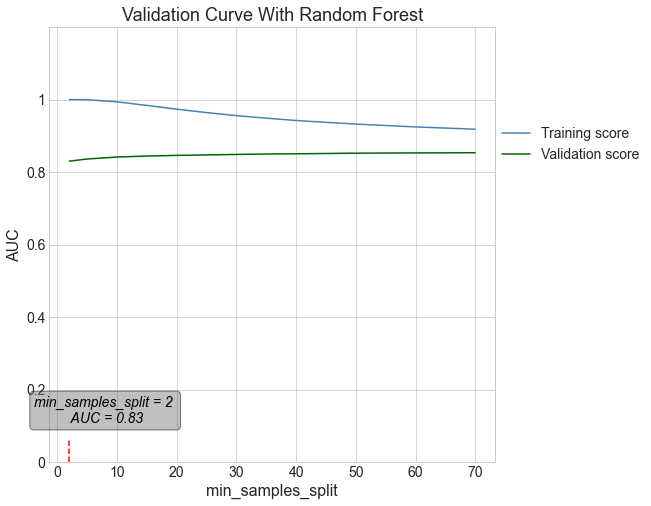

In [43]:
plt.style.use("seaborn-whitegrid")

plt.subplots(1, figsize = (8,8))

plt.plot(eje_x, eje_y_train, label = "Training score", color = "steelblue")
plt.plot(eje_x, eje_y_val, label = "Validation score", color = "darkgreen")

plt.title("Validation Curve With Random Forest", fontsize = 18)
plt.xlabel("min_samples_split", fontsize = 16)
plt.ylabel("AUC", fontsize = 16)

plt.yticks(ticks = [0, 0.2, 0.4, 0.6, 0.8, 1], labels = [0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 14) 
plt.xticks(fontsize = 14)
#plt.xticks(ticks = range(0, 21, 2), labels = range(0, 21, 2), fontsize = 14)
plt.ylim(0, 1.2)

plt.axvline(2, ymax = 0.055, color = "red", linestyle = "--")
style = dict(size = 14, color = 'black', fontstyle = "oblique")
props = dict(boxstyle = "round", facecolor = "grey", alpha = 0.5)
plt.text(8, 0.1, f"min_samples_split = 2 \n AUC = {eje_y_val[0].round(2)}", ha = "center", va = "bottom", **style, bbox = props)

plt.legend(fontsize = 14, bbox_to_anchor = (1.35, 0.8))

plt.show()

`min_samples_split = ???` will be used as a reference value.

#### A.2.4 min_samples_leaf

In [44]:
min_samples_leaf = np.arange(1,16,1) 

In [45]:
start = datetime.datetime.now()

eje_x = []
eje_y_train = []
eje_y_val = []

for i in min_samples_leaf:    
    # We instantiate the model
    rf_clf = RandomForestClassifier(min_samples_leaf = i, random_state = 123)
    
    # Fitting
    rf_clf.fit(X_train_std, y_train)
    
    # Predicting
    y_train_pred_proba_rf = rf_clf.predict_proba(X_train_std)
    y_val_pred_proba_rf = rf_clf.predict_proba(X_val_std)

    # AUC
    train_roc_auc_score_rf = roc_auc_score(y_train, y_train_pred_proba_rf[:, 1])
    val_roc_auc_score_rf = roc_auc_score(y_val, y_val_pred_proba_rf[:, 1])
    
    # Appending
    eje_x.append(i)
    eje_y_train.append(train_roc_auc_score_rf)
    eje_y_val.append(val_roc_auc_score_rf)
    
end = datetime.datetime.now()
delta = round((end - start).seconds / 60, 2)
print(f"Time it took to search n_estimators: {delta} minutes.")

Time it took to search n_estimators: 4.25 minutes.


In [46]:
eje_y_train

[0.999999999358435,
 0.9968291128330122,
 0.9849102722177538,
 0.9712627483481853,
 0.9593113413277181,
 0.9490933029113947,
 0.9398114479792528,
 0.9321757050301654,
 0.9258879851210688,
 0.9210308374694184,
 0.916683459151657,
 0.9119043926978019,
 0.9089050177721003,
 0.9061782813034217,
 0.9034767373314234]

In [47]:
eje_y_val

[0.8302782386437901,
 0.8416583073847679,
 0.8452355272728256,
 0.848137921375216,
 0.849418374718993,
 0.8506870747572921,
 0.8519558312525171,
 0.8523930824447598,
 0.8532098768692155,
 0.8539545180592887,
 0.854141209565155,
 0.8544834386186995,
 0.8546829740752029,
 0.855275699942638,
 0.8555500215792485]

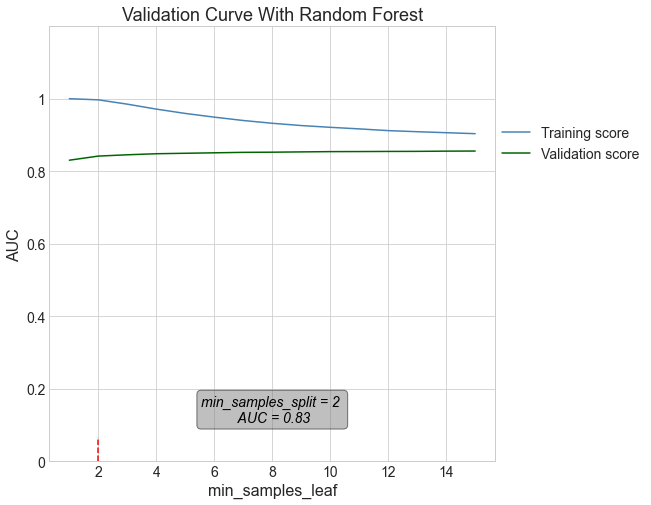

In [48]:
plt.style.use("seaborn-whitegrid")

plt.subplots(1, figsize = (8,8))

plt.plot(eje_x, eje_y_train, label = "Training score", color = "steelblue")
plt.plot(eje_x, eje_y_val, label = "Validation score", color = "darkgreen")

plt.title("Validation Curve With Random Forest", fontsize = 18)
plt.xlabel("min_samples_leaf", fontsize = 16)
plt.ylabel("AUC", fontsize = 16)

plt.yticks(ticks = [0, 0.2, 0.4, 0.6, 0.8, 1], labels = [0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 14) 
plt.xticks(fontsize = 14)
#plt.xticks(ticks = range(0, 21, 2), labels = range(0, 21, 2), fontsize = 14)
plt.ylim(0, 1.2)

plt.axvline(2, ymax = 0.055, color = "red", linestyle = "--")
style = dict(size = 14, color = 'black', fontstyle = "oblique")
props = dict(boxstyle = "round", facecolor = "grey", alpha = 0.5)
plt.text(8, 0.1, f"min_samples_split = 2 \n AUC = {eje_y_val[0].round(2)}", ha = "center", va = "bottom", **style, bbox = props)

plt.legend(fontsize = 14, bbox_to_anchor = (1.35, 0.8))

plt.show()

#### A.2.5 Putting all togheter

In [49]:
rf_tunning = RandomForestClassifier(n_estimators = 50, max_depth = 10, min_samples_split = 70, min_samples_leaf = 15, random_state = 123)

For RandomForestClassifier :
	Train Precision Score:0.788
	Validation Precision Score:0.643
	---	---	---	---
	Train Recall Score:0.001
	Validation Recall Score:0.001
	---	---	---	---
	Train ROC AUC Score:0.862
	Validation ROC AUC Score:0.858
------------------------------------------------------------------------------------------------------


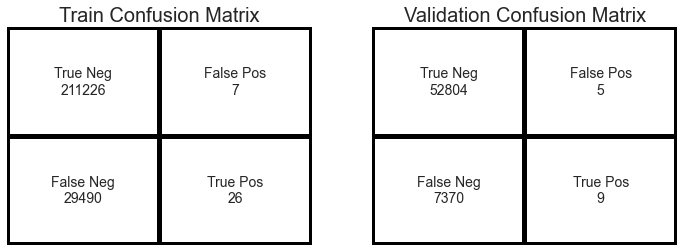

------------------------------------------------------------------------------------------------------


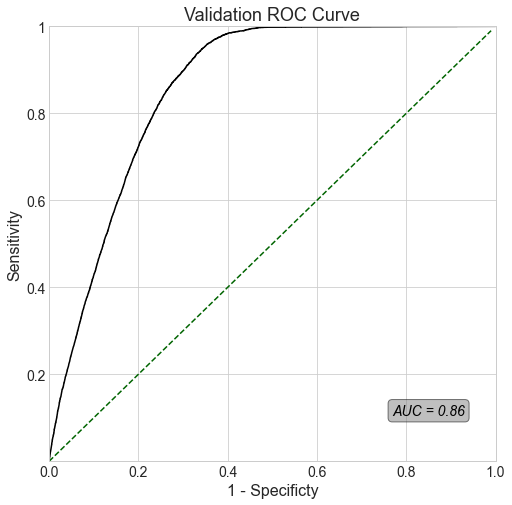

------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     52809
           1       0.64      0.00      0.00      7379

    accuracy                           0.88     60188
   macro avg       0.76      0.50      0.47     60188
weighted avg       0.85      0.88      0.82     60188



In [50]:
fit_train_val(rf_tunning)

#### A.2.6 RF tunning hyperparameters append results

In [51]:
rf_tunning_train_recall = round(recall_score(y_train, rf_tunning.predict(X_train_std)), 2)
rf_tunning_val_recall = round(recall_score(y_val, rf_tunning.predict(X_val_std)), 2)

rf_tunning_train_precision = round(precision_score(y_train, rf_tunning.predict(X_train_std)), 2)
rf_tunning_val_precision = round(precision_score(y_val, rf_tunning.predict(X_val_std)), 2)

rf_tunning_train_auc = round(roc_auc_score(y_train, rf_tunning.predict_proba(X_train_std)[:, 1]), 2)
rf_tunning_val_auc = round(roc_auc_score(y_val, rf_tunning.predict_proba(X_val_std)[:, 1]), 2)

rf_tunning_val_cf_matrix = confusion_matrix(y_val, rf_tunning.predict(X_val_std))

In [52]:
rf_tunning_results = pd.DataFrame({"Model": ["RF with tunning"], 
                                   "Train Recall": [rf_tunning_train_recall], "Validation Recall": [rf_tunning_val_recall], 
                                   "Train Precision": [rf_tunning_train_precision], "Validation Precision": [rf_tunning_val_precision], 
                                   "Val TP": [rf_tunning_val_cf_matrix[1,1]], "Val FP": [rf_tunning_val_cf_matrix[1,0]], "Val TN": [rf_tunning_val_cf_matrix[0,0]], "Val FN": [rf_tunning_val_cf_matrix[0,1]],
                                   "Train AUC": [rf_tunning_train_auc], "Validation AUC": [rf_tunning_val_auc]})

In [53]:
model_results = pd.concat([model_results, rf_tunning_results], axis = 0, ignore_index = True)

### A.3 GridSearch CV

The param_grid is created

In [54]:
rf = RandomForestClassifier(random_state = 123)

In [55]:
param_grid = { 
    "n_estimators": [50, 100, 1000],
    "max_features": ["sqrt", "log2"],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 70, 100],
    #"min_samples_leaf": [10, 15, 20],
    "criterion":["gini", "entropy"]
}

In [56]:
rf_gcv = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 3, scoring = "roc_auc", n_jobs = -1, verbose = 1)

In [57]:
start = datetime.datetime.now()

rf_gcv.fit(X_train_std, y_train)

end = datetime.datetime.now()
delta = round((end - start).seconds / 60, 2)
print(f"Time it took to fit: {delta} minutes.")

Fitting 3 folds for each of 108 candidates, totalling 324 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  3.1min
/Users/maia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed: 25.0min
[Parallel(n_jobs=-1)]: Done 324 out of 324 | elapsed: 49.4min finished


Time it took to fit: 49.6 minutes.


In [58]:
# Fitting 3 folds for each of 108 candidates, totalling 324 fits

rf_gcv.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_split': 100,
 'n_estimators': 100}

In [59]:
rf_gcv_model = rf_gcv.best_estimator_

In [60]:
rf_gcv_model = RandomForestClassifier(criterion = "gini", max_depth = 10, max_features = "sqrt", min_samples_split = 100, n_estimators = 100, random_state = 123)

For RandomForestClassifier :
	Train Precision Score:0.808
	Validation Precision Score:0.600
	---	---	---	---
	Train Recall Score:0.002
	Validation Recall Score:0.002
	---	---	---	---
	Train ROC AUC Score:0.863
	Validation ROC AUC Score:0.859
------------------------------------------------------------------------------------------------------


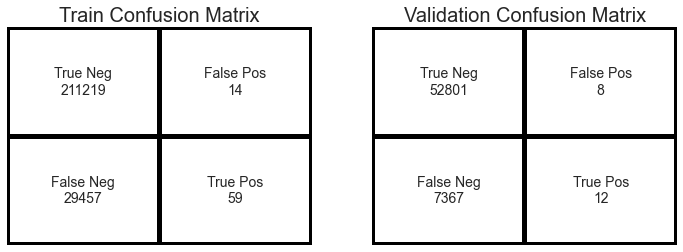

------------------------------------------------------------------------------------------------------


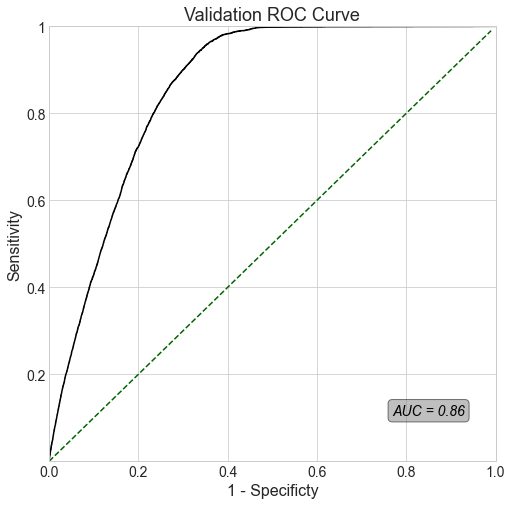

------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     52809
           1       0.60      0.00      0.00      7379

    accuracy                           0.88     60188
   macro avg       0.74      0.50      0.47     60188
weighted avg       0.84      0.88      0.82     60188



In [61]:
fit_train_val(rf_gcv_model)

#### A.3.1 RF tunning hyperparameters with GridSearch CV append results

In [62]:
rf_gcv_model_train_recall = round(recall_score(y_train, rf_gcv_model.predict(X_train_std)), 2)
rf_gcv_model_val_recall = round(recall_score(y_val, rf_gcv_model.predict(X_val_std)), 2)

rf_gcv_model_train_precision = round(precision_score(y_train, rf_gcv_model.predict(X_train_std)), 2)
rf_gcv_model_val_precision = round(precision_score(y_val, rf_gcv_model.predict(X_val_std)), 2)

rf_gcv_model_train_auc = round(roc_auc_score(y_train, rf_gcv_model.predict_proba(X_train_std)[:, 1]), 2)
rf_gcv_model_val_auc = round(roc_auc_score(y_val, rf_gcv_model.predict_proba(X_val_std)[:, 1]), 2)

rf_gcv_model_val_cf_matrix = confusion_matrix(y_val, rf_gcv_model.predict(X_val_std))

In [63]:
rf_gcv_model_results = pd.DataFrame({"Model": ["RF tunning with GridSearchCV"], 
                                     "Train Recall": [rf_gcv_model_train_recall], "Validation Recall": [rf_gcv_model_val_recall], 
                                     "Train Precision": [rf_gcv_model_train_precision], "Validation Precision": [rf_gcv_model_val_precision], 
                                     "Val TP": [rf_gcv_model_val_cf_matrix[1,1]], "Val FP": [rf_gcv_model_val_cf_matrix[1,0]], "Val TN": [rf_gcv_model_val_cf_matrix[0,0]], "Val FN": [rf_gcv_model_val_cf_matrix[0,1]],
                                     "Train AUC": [rf_gcv_model_train_auc], "Validation AUC": [rf_gcv_model_val_auc]})

In [64]:
model_results = pd.concat([model_results, rf_gcv_model_results], axis = 0, ignore_index = True)

In [65]:
model_results

,Model,Train Recall,Validation Recall,Train Precision,Validation Precision,Val TP,Val FP,Val TN,Val FN,Train AUC,Validation AUC
0,RF without tunning,1.0,0.16,1.00,0.34,1159.0,6220.0,50596.0,2213.0,1.00,0.83
1,RF with tunning,0.0,0.00,0.79,0.64,9.0,7370.0,52804.0,5.0,0.86,0.86
2,RF tunning with GridSearchCV,0.0,0.00,0.81,0.60,12.0,7367.0,52801.0,8.0,0.86,0.86


In [66]:
from sklearn.linear_model import LogisticRegression


In [67]:
lr = LogisticRegression()

For LogisticRegression :
	Train Precision Score:0.115
	Validation Precision Score:0.000
	---	---	---	---
	Train Recall Score:0.000
	Validation Recall Score:0.000
	---	---	---	---
	Train ROC AUC Score:0.850
	Validation ROC AUC Score:0.851
------------------------------------------------------------------------------------------------------


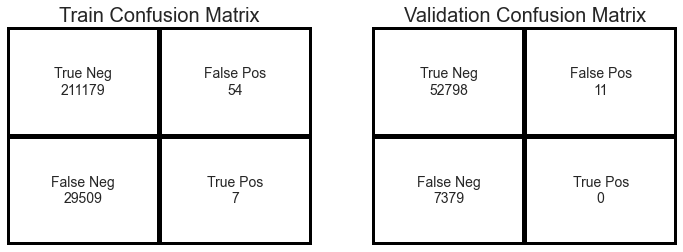

------------------------------------------------------------------------------------------------------


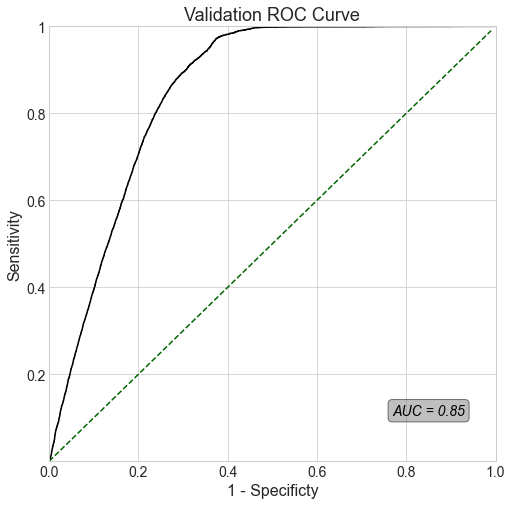

------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     52809
           1       0.00      0.00      0.00      7379

    accuracy                           0.88     60188
   macro avg       0.44      0.50      0.47     60188
weighted avg       0.77      0.88      0.82     60188



In [70]:
fit_train_val(lr)

In [71]:
lr_train_recall = round(recall_score(y_train, lr.predict(X_train_std)), 2)
lr_val_recall = round(recall_score(y_val, lr.predict(X_val_std)), 2)

lr_train_precision = round(precision_score(y_train, lr.predict(X_train_std)), 2)
lr_val_precision = round(precision_score(y_val, lr.predict(X_val_std)), 2)

lr_train_auc = round(roc_auc_score(y_train, lr.predict_proba(X_train_std)[:, 1]), 2)
lr_val_auc = round(roc_auc_score(y_val, lr.predict_proba(X_val_std)[:, 1]), 2)

lr_val_cf_matrix = confusion_matrix(y_val, lr.predict(X_val_std))

In [72]:
lr_results = pd.DataFrame({"Model": ["Logistic Regression"], 
                           "Train Recall": [lr_train_recall], "Validation Recall": [lr_val_recall], 
                           "Train Precision": [lr_train_precision], "Validation Precision": [lr_val_precision], 
                           "Val TP": [lr_val_cf_matrix[1,1]], "Val FP": [lr_val_cf_matrix[1,0]], "Val TN": [lr_val_cf_matrix[0,0]], "Val FN": [lr_val_cf_matrix[0,1]],
                           "Train AUC": [lr_train_auc], "Validation AUC": [lr_val_auc]})

In [77]:
model_results = pd.concat([model_results, lr_results], axis = 0, ignore_index = True)
model_results

,Model,Train Recall,Validation Recall,Train Precision,Validation Precision,Val TP,Val FP,Val TN,Val FN,Train AUC,Validation AUC
0,RF without tunning,1.0,0.16,1.00,0.34,1159.0,6220.0,50596.0,2213.0,1.00,0.83
1,RF with tunning,0.0,0.00,0.79,0.64,9.0,7370.0,52804.0,5.0,0.86,0.86
2,RF tunning with GridSearchCV,0.0,0.00,0.81,0.60,12.0,7367.0,52801.0,8.0,0.86,0.86
3,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
4,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
5,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
6,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
7,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85


For AdaBoostClassifier :
	Train Precision Score:1.000
	Validation Precision Score:0.319
	---	---	---	---
	Train Recall Score:1.000
	Validation Recall Score:0.215
	---	---	---	---
	Train ROC AUC Score:1.000
	Validation ROC AUC Score:0.787
------------------------------------------------------------------------------------------------------


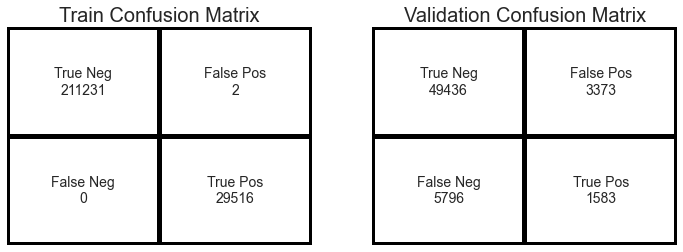

------------------------------------------------------------------------------------------------------


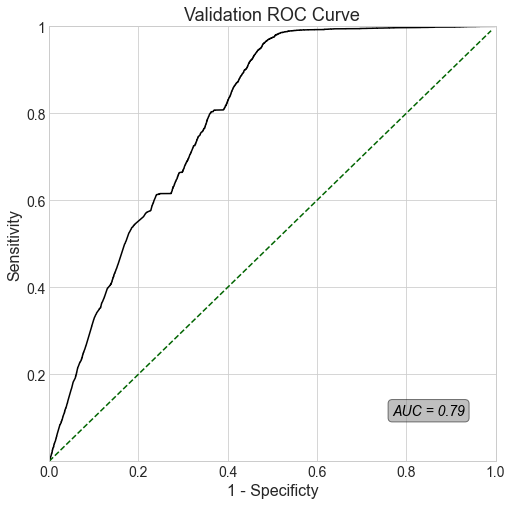

------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     52809
           1       0.32      0.21      0.26      7379

    accuracy                           0.85     60188
   macro avg       0.61      0.58      0.59     60188
weighted avg       0.82      0.85      0.83     60188



In [80]:
dt = DecisionTreeClassifier(random_state=1)
ab = AdaBoostClassifier(base_estimator=dt, n_estimators=500,random_state=1)

fit_train_val(ab)

In [83]:
ab_train_recall = round(recall_score(y_train, ab.predict(X_train_std)), 2)
ab_val_recall = round(recall_score(y_val, ab.predict(X_val_std)), 2)

ab_train_precision = round(precision_score(y_train, ab.predict(X_train_std)), 2)
ab_val_precision = round(precision_score(y_val, ab.predict(X_val_std)), 2)

ab_train_auc = round(roc_auc_score(y_train, ab.predict_proba(X_train_std)[:, 1]), 2)
ab_val_auc = round(roc_auc_score(y_val, ab.predict_proba(X_val_std)[:, 1]), 2)

ab_val_cf_matrix = confusion_matrix(y_val, ab.predict(X_val_std))

In [84]:
ab_results = pd.DataFrame({"Model": ["AdaBoost "], 
                           "Train Recall": [ab_train_recall], "Validation Recall": [ab_val_recall], 
                           "Train Precision": [ab_train_precision], "Validation Precision": [ab_val_precision], 
                           "Val TP": [ab_val_cf_matrix[1,1]], "Val FP": [ab_val_cf_matrix[1,0]], "Val TN": [ab_val_cf_matrix[0,0]], "Val FN": [lr_val_cf_matrix[0,1]],
                           "Train AUC": [ab_train_auc], "Validation AUC": [ab_val_auc]})

In [85]:
ab_results

,Model,Train Recall,Validation Recall,Train Precision,Validation Precision,Val TP,Val FP,Val TN,Val FN,Train AUC,Validation AUC
0,AdaBoost,1.0,0.21,1.0,0.32,1583,5796,49436,11,1.0,0.79


In [96]:
model_results = pd.concat([model_results, ab_results], axis = 0, ignore_index = True)
model_results

,Model,Train Recall,Validation Recall,Train Precision,Validation Precision,Val TP,Val FP,Val TN,Val FN,Train AUC,Validation AUC
0,RF without tunning,1.0,0.16,1.00,0.34,1159.0,6220.0,50596.0,2213.0,1.00,0.83
1,RF with tunning,0.0,0.00,0.79,0.64,9.0,7370.0,52804.0,5.0,0.86,0.86
2,RF tunning with GridSearchCV,0.0,0.00,0.81,0.60,12.0,7367.0,52801.0,8.0,0.86,0.86
3,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
4,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
5,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
6,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
7,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
8,AdaBoost,1.0,0.21,1.00,0.32,1583.0,5796.0,49436.0,11.0,1.00,0.79


In [89]:
ab_gcv = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 3, scoring = "roc_auc", n_jobs = -1, verbose = 1)


In [90]:
start = datetime.datetime.now()

ab_gcv.fit(X_train_std, y_train)

end = datetime.datetime.now()
delta = round((end - start).seconds / 60, 2)
print(f"Time it took to fit: {delta} minutes.")

Fitting 3 folds for each of 108 candidates, totalling 324 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  3.1min
/Users/maia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed: 25.2min
[Parallel(n_jobs=-1)]: Done 324 out of 324 | elapsed: 56.3min finished


Time it took to fit: 56.43 minutes.


In [92]:
ab_gcv.best_params_


{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_split': 100,
 'n_estimators': 100}

In [93]:
ab_gcv_model = ab_gcv.best_estimator_


In [94]:
ab_gcv_model

RandomForestClassifier(max_depth=10, max_features='sqrt', min_samples_split=100,
                       random_state=123)

For RandomForestClassifier :
	Train Precision Score:0.808
	Validation Precision Score:0.600
	---	---	---	---
	Train Recall Score:0.002
	Validation Recall Score:0.002
	---	---	---	---
	Train ROC AUC Score:0.863
	Validation ROC AUC Score:0.859
------------------------------------------------------------------------------------------------------


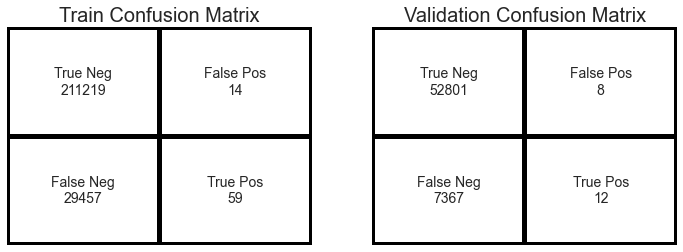

------------------------------------------------------------------------------------------------------


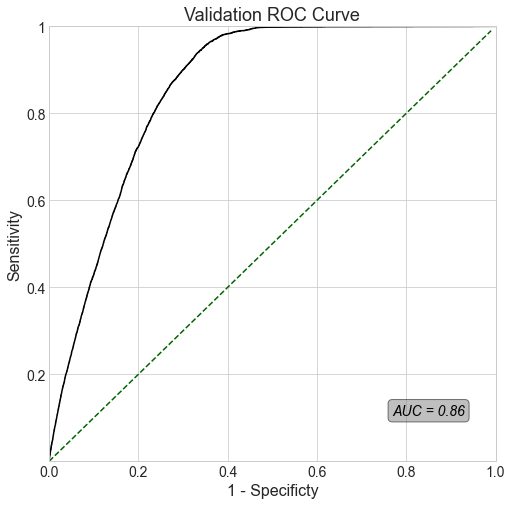

------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     52809
           1       0.60      0.00      0.00      7379

    accuracy                           0.88     60188
   macro avg       0.74      0.50      0.47     60188
weighted avg       0.84      0.88      0.82     60188



In [95]:
fit_train_val(ab_gcv_model)

In [100]:
ab_gcv_train_recall = round(recall_score(y_train, ab_gcv.predict(X_train_std)), 2)
ab_gcv_val_recall = round(recall_score(y_val, ab_gcv.predict(X_val_std)), 2)

ab_gcv_train_precision = round(precision_score(y_train, ab_gcv.predict(X_train_std)), 2)
ab_gcv_val_precision = round(precision_score(y_val, ab_gcv.predict(X_val_std)), 2)

ab_gcv_train_auc = round(roc_auc_score(y_train, ab_gcv.predict_proba(X_train_std)[:, 1]), 2)
ab_gcv_val_auc = round(roc_auc_score(y_val, ab_gcv.predict_proba(X_val_std)[:, 1]), 2)

ab_gcv_val_cf_matrix = confusion_matrix(y_val, ab_gcv.predict(X_val_std))

In [101]:
ab_gcv_results = pd.DataFrame({"Model": ["AdaBoost with tunning "], 
                           "Train Recall": [ab_gcv_train_recall], "Validation Recall": [ab_gcv_val_recall], 
                           "Train Precision": [ab_gcv_train_precision], "Validation Precision": [ab_gcv_val_precision], 
                           "Val TP": [ab_gcv_val_cf_matrix[1,1]], "Val FP": [ab_gcv_val_cf_matrix[1,0]], "Val TN": [ab_val_cf_matrix[0,0]], "Val FN": [lr_val_cf_matrix[0,1]],
                           "Train AUC": [ab_gcv_train_auc], "Validation AUC": [ab_gcv_val_auc]})

In [102]:
ab_gcv_results

,Model,Train Recall,Validation Recall,Train Precision,Validation Precision,Val TP,Val FP,Val TN,Val FN,Train AUC,Validation AUC
0,AdaBoost with tunning,0.0,0.0,0.81,0.6,12,7367,49436,11,0.86,0.86


In [103]:
model_results = pd.concat([model_results, ab_gcv_results], axis = 0, ignore_index = True)
model_results

,Model,Train Recall,Validation Recall,Train Precision,Validation Precision,Val TP,Val FP,Val TN,Val FN,Train AUC,Validation AUC
0,RF without tunning,1.0,0.16,1.00,0.34,1159.0,6220.0,50596.0,2213.0,1.00,0.83
1,RF with tunning,0.0,0.00,0.79,0.64,9.0,7370.0,52804.0,5.0,0.86,0.86
2,RF tunning with GridSearchCV,0.0,0.00,0.81,0.60,12.0,7367.0,52801.0,8.0,0.86,0.86
3,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
4,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
5,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
6,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
7,Logistic Regression,0.0,0.00,0.11,0.00,0.0,7379.0,52798.0,11.0,0.85,0.85
8,AdaBoost,1.0,0.21,1.00,0.32,1583.0,5796.0,49436.0,11.0,1.00,0.79
9,AdaBoost with tunning,0.0,0.00,0.81,0.60,12.0,7367.0,49436.0,11.0,0.86,0.86


In [108]:
import shap
# Fits the explainer
explainer = shap.Explainer(ab_gcv_model.predict, X_val_std)
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_val_std)

Permutation explainer: 60189it [22:25:47,  1.34s/it]                            


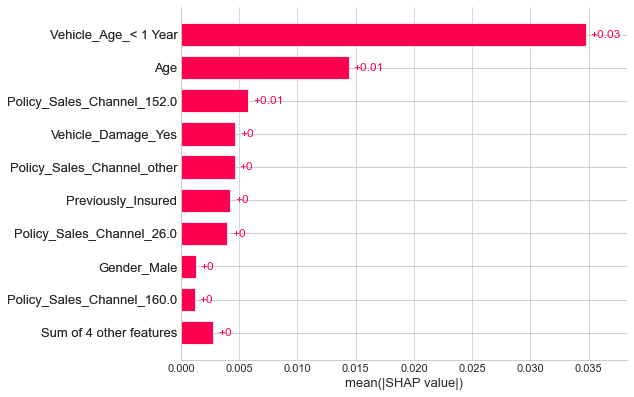

In [109]:
shap.plots.bar(shap_values)


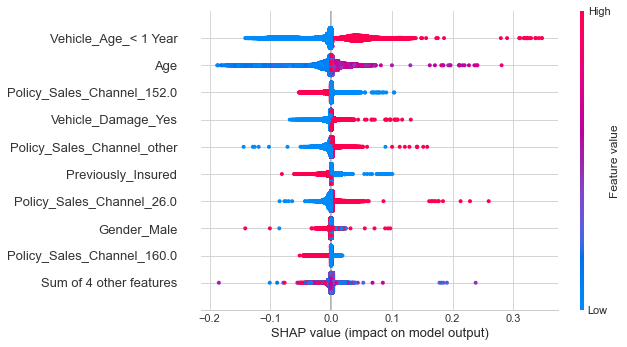

In [110]:
shap.plots.beeswarm(shap_values)


In [112]:
#For example, high values of the Vechicle_Age variable have a high negative contribution on the prediction, while low values have a high positive contribution.



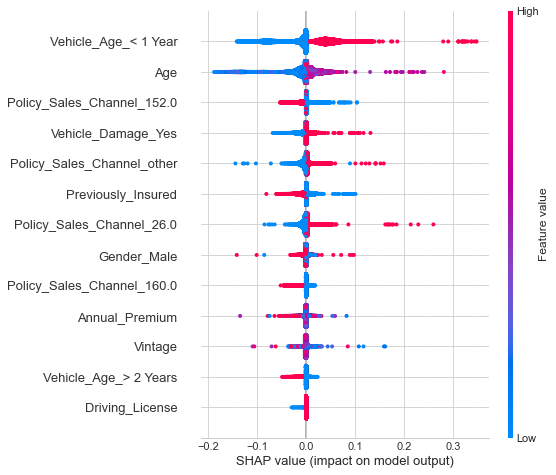

In [111]:
shap.summary_plot(shap_values)


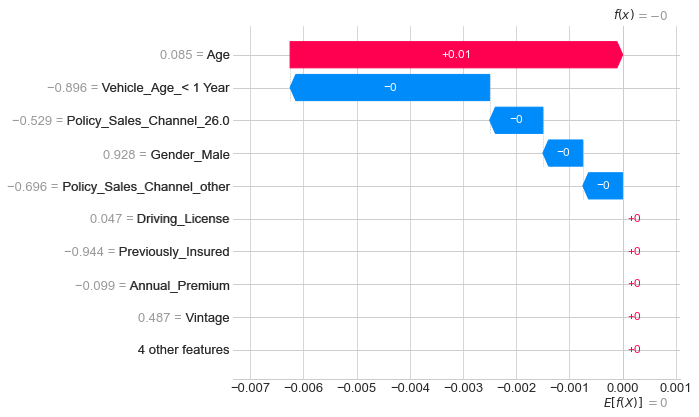

In [115]:
shap.plots.waterfall(shap_values[0])
